In [1]:
import polars as pl
pl.Config.set_tbl_rows(20)

polars.config.Config

# Preprocessing

In [2]:
df_ling = pl.read_csv("rq1_ling_predictions.csv")
df_sbert = pl.read_csv("results/rq1_sbert_predictions.csv")

In [ ]:
df_ling.shape[0] + df_sbert.shape[0]

12098554

In [3]:
df_ling = df_ling.filter(pl.col("feature_area") == "all_features")
df_ling = df_ling.drop("feature_area")

In [4]:
df_ling = df_ling.with_columns(
    pl.when(pl.col("true_label") == pl.col("predicted_label"))
    .then(1)
    .otherwise(0)
    .alias("correct")
)
df_sbert = df_sbert.with_columns(
    pl.when(pl.col("true_label") == pl.col("predicted_label"))
    .then(1)
    .otherwise(0)
    .alias("correct")
)

In [5]:
# calculate the number of correct predictions per argument_id
df_ling.group_by("argument_id").agg(pl.sum("correct").alias("num_correct")).sort("num_correct", descending=True)

argument_id,num_correct
str,i32
"""202307149""",64
"""202304307""",64
"""202304345""",64
"""202302772""",64
"""202309388""",64
"""202305728""",64
"""2023012685""",64
"""202301012""",64
"""202307857""",64


In [6]:
df_ling["argument_id"].value_counts().sort("count", descending=True)

argument_id,count
str,u32
"""202309906""",64
"""20230105""",64
"""2023010320""",64
"""202307182""",64
"""2023013167""",64
"""2023010064""",64
"""2023012612""",64
"""2023011062""",64
"""202301045""",64


In [7]:
df_ling.head()

argument_id,true_label,predicted_label,raw_prediction_score,prob_human,prob_model,fold,model,condition,language,topic,stance,correct
str,i64,i64,f64,f64,f64,i64,str,str,str,str,str,i32
"""chatcmpl-CQbXWC83cghpXSEKYsxTV…",0,0,-0.49326,0.257676,0.742324,0,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""",1
"""chatcmpl-CQcG6x3hllYz7hNswpYsd…",0,0,-0.803365,0.120837,0.879163,0,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""",1
"""chatcmpl-CQcG7mEPhVdHq9kUlHBdz…",0,0,-0.134596,0.5,0.5,0,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""",1
"""2023033""",1,1,2.952808,1.0,2.8437e-8,0,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""",1
"""20230289""",1,1,1.118859,0.977214,0.022786,0,"""gpt-4.1-mini""","""Default""","""de""","""Democracy, Media & Digitizatio…","""FAVOR""",1


In [8]:
# calculate percentage of correct predictions per argument_id
df_ling = df_ling.with_columns(
    pl.col("correct").sum().over("argument_id").alias("num_correct"),
    pl.col("correct").count().over("argument_id").alias("num_total"),
)
df_ling = df_ling.with_columns(
    (pl.col("num_correct") / pl.col("num_total")).alias("percentage_correct")
)

df_sbert = df_sbert.with_columns(
    pl.col("correct").sum().over("argument_id").alias("num_correct"),
    pl.col("correct").count().over("argument_id").alias("num_total"),
)
df_sbert = df_sbert.with_columns(
    (pl.col("num_correct") / pl.col("num_total")).alias("percentage_correct")
)

# calculate the average prob_human, prob_model, standard deviation of prob_human, standard deviation of prob_model per argument_id
df_ling = df_ling.with_columns(
    pl.col("prob_human").mean().over("argument_id").alias("avg_prob_human"),
    pl.col("prob_model").mean().over("argument_id").alias("avg_prob_model"),
    pl.col("prob_human").std().over("argument_id").alias("std_prob_human"),
    pl.col("prob_model").std().over("argument_id").alias("std_prob_model"),
)
df_sbert = df_sbert.with_columns(
    pl.col("prob_human").mean().over("argument_id").alias("avg_prob_human"),
    pl.col("prob_model").mean().over("argument_id").alias("avg_prob_model"),
    pl.col("prob_human").std().over("argument_id").alias("std_prob_human"),
    pl.col("prob_model").std().over("argument_id").alias("std_prob_model"),
)

# Error Analysis

## Aggregate Confusion Matrices

LLM, predicted as human

In [16]:
df_ling.filter(pl.col("true_label") == 0, pl.col("correct") == 0)["model"].value_counts().sort("count", descending=True)

model,count
str,u32
"""occiglot-7b-eu5-instruct""",1814
"""llama_3.1-8b-instruct""",579
"""llama_4_scout""",558
"""gpt-4.1-mini""",261


In [17]:
df_sbert.filter(pl.col("true_label") == 0, pl.col("correct") == 0)["model"].value_counts().sort("count", descending=True)

model,count
str,u32
"""occiglot-7b-eu5-instruct""",2186
"""llama_3.1-8b-instruct""",1850
"""llama_4_scout""",555
"""gpt-4.1-mini""",284


LLM, predicted as LLM

In [18]:
df_ling.filter(pl.col("true_label") == 0, pl.col("correct") == 1)["model"].value_counts().sort("count", descending=True)

model,count
str,u32
"""gpt-4.1-mini""",88491
"""llama_4_scout""",88194
"""occiglot-7b-eu5-instruct""",83271
"""llama_3.1-8b-instruct""",81318


In [19]:
df_sbert.filter(pl.col("true_label") == 0, pl.col("correct") == 1)["model"].value_counts().sort("count", descending=True)

model,count
str,u32
"""gpt-4.1-mini""",88498
"""llama_4_scout""",88227
"""occiglot-7b-eu5-instruct""",82899
"""llama_3.1-8b-instruct""",80047


Human, predicted as human

In [20]:
df_ling.filter(pl.col("true_label") == 1, pl.col("correct") == 1)["model"].value_counts().sort("count", descending=True)

model,count
str,u32
"""gpt-4.1-mini""",145932
"""llama_4_scout""",145576
"""occiglot-7b-eu5-instruct""",145167
"""llama_3.1-8b-instruct""",144539


In [21]:
df_sbert.filter(pl.col("true_label") == 1, pl.col("correct") == 1)["model"].value_counts().sort("count", descending=True)

model,count
str,u32
"""llama_4_scout""",143310
"""occiglot-7b-eu5-instruct""",142258
"""gpt-4.1-mini""",141832
"""llama_3.1-8b-instruct""",137363


Human, predicted as LLM

In [22]:
df_ling.filter(pl.col("true_label") == 1, pl.col("correct") == 0)["model"].value_counts().sort("count", descending=True)

model,count
str,u32
"""llama_4_scout""",1738
"""occiglot-7b-eu5-instruct""",1452
"""gpt-4.1-mini""",1382
"""llama_3.1-8b-instruct""",220


In [23]:
df_sbert.filter(pl.col("true_label") == 1, pl.col("correct") == 0)["model"].value_counts().sort("count", descending=True)

model,count
str,u32
"""llama_3.1-8b-instruct""",7396
"""gpt-4.1-mini""",6531
"""llama_4_scout""",5053
"""occiglot-7b-eu5-instruct""",4361


In [25]:
df_ling.columns

['argument_id',
 'true_label',
 'predicted_label',
 'raw_prediction_score',
 'prob_human',
 'prob_model',
 'fold',
 'model',
 'condition',
 'language',
 'topic',
 'stance',
 'correct',
 'num_correct',
 'num_total',
 'percentage_correct']

/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_21427/3920905508.py:22: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ).agg(pl.count().alias("count"))
/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_21427/3920905508.py:22: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ).agg(pl.count().alias("count"))
/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_21427/3920905508.py:22: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ).agg(pl.count().alias("count"))
/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_21427/3920905508.py:22: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ).agg(pl.count().alias("count"))


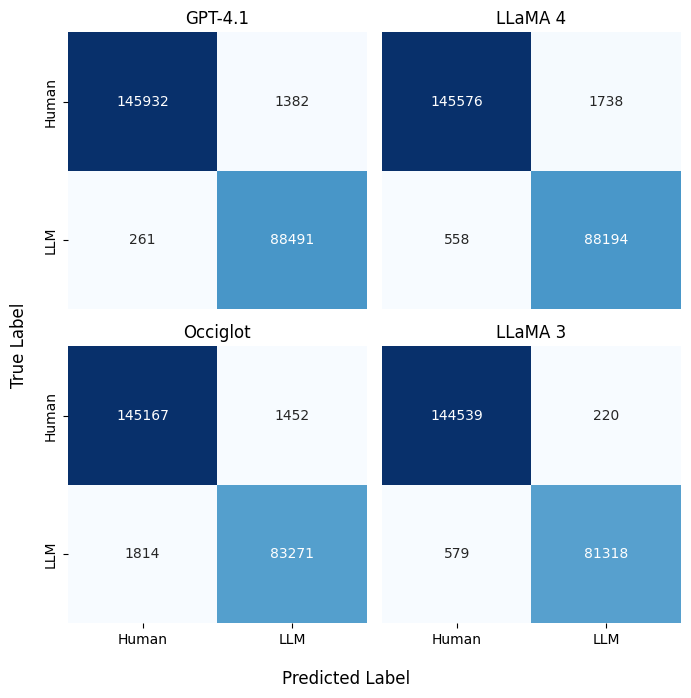

In [51]:
# heatmap per model in a 2x2 grid for linguistic features
import matplotlib.pyplot as plt
import seaborn as sns

# model names
model_names = {
    "gpt-4.1-mini": "GPT-4.1",
    "llama_4_scout": "LLaMA 4",
    "occiglot-7b-eu5-instruct": "Occiglot",
    "llama_3.1-8b-instruct": "LLaMA 3"
}

models = ["gpt-4.1-mini", "llama_4_scout", "occiglot-7b-eu5-instruct", "llama_3.1-8b-instruct"]


fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for i, model in enumerate(models):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    data = df_ling.filter(pl.col("model") == model).group_by(
        ["true_label", "predicted_label"]
    ).agg(pl.count().alias("count"))
    data = data.to_pandas()
    data["true_label"] = data["true_label"].map({0: "LLM", 1: "Human"})
    data["predicted_label"] = data["predicted_label"].map({0: "LLM", 1: "Human"})
    pivot_table = data.pivot(index="true_label", columns="predicted_label", values="count")

    # Only show yticklabels on left column, xticklabels on bottom row
    xticklabels = (row == 1)
    yticklabels = (col == 0)

    sns.heatmap(pivot_table, annot=True, fmt="d", cmap="Blues", ax=ax,
                cbar=False, xticklabels=xticklabels, yticklabels=yticklabels)
    ax.set_title(model_names.get(model, model))

    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supxlabel("Predicted Label", fontsize=12)
fig.supylabel("True Label", fontsize=12)

plt.tight_layout()
plt.savefig("figures/ling_confusion.pdf", dpi=300, bbox_inches="tight",
            pad_inches=0.1, transparent=True,
            format="pdf")
plt.show()

/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_21427/3350805065.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ).agg(pl.count().alias("count"))
/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_21427/3350805065.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ).agg(pl.count().alias("count"))
/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_21427/3350805065.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ).agg(pl.count().alias("count"))
/var/folders/bn/zpqsg90d5y3g9k334bz2cb600000gn/T/ipykernel_21427/3350805065.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ).agg(pl.count().alias("count"))


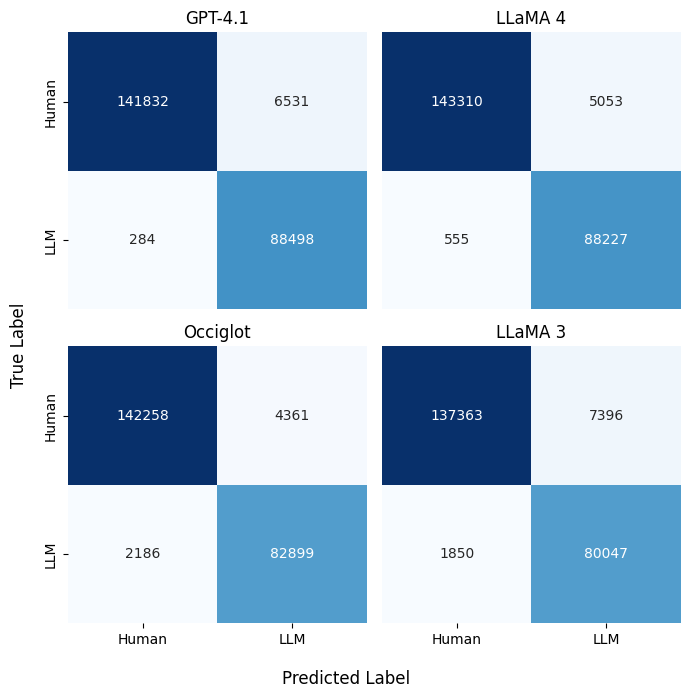

In [52]:
# heatmap per model in a 2x2 grid for sbert features
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for i, model in enumerate(models):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    data = df_sbert.filter(pl.col("model") == model).group_by(
        ["true_label", "predicted_label"]
    ).agg(pl.count().alias("count"))
    data = data.to_pandas()
    data["true_label"] = data["true_label"].map({0: "LLM", 1: "Human"})
    data["predicted_label"] = data["predicted_label"].map({0: "LLM", 1: "Human"})
    pivot_table = data.pivot(index="true_label", columns="predicted_label", values="count")

    # Only show yticklabels on left column, xticklabels on bottom row
    xticklabels = (row == 1)
    yticklabels = (col == 0)

    sns.heatmap(pivot_table, annot=True, fmt="d", cmap="Blues", ax=ax,
                cbar=False, xticklabels=xticklabels, yticklabels=yticklabels)
    ax.set_title(model_names.get(model, model))

    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supxlabel("Predicted Label", fontsize=12)
fig.supylabel("True Label", fontsize=12)

plt.tight_layout()
plt.savefig("figures/sbert_confusion.pdf", dpi=300, bbox_inches="tight",
            pad_inches=0.1, transparent=True,
            format="pdf")
plt.show()

## Statistics on Errors

In [9]:
# merge the two dfs on unique rows (argument_id, model, num_correct, num_total, percentage_correct, avg_prob_human, avg_prob_model, std_prob_human, std_prob_model)
df = df_ling.select([
    "argument_id", "model", "condition", "num_correct", "num_total",
    "percentage_correct", "avg_prob_human", "avg_prob_model",
    "std_prob_human", "std_prob_model"
]).join(df_sbert.select([
    "argument_id", "model", "num_correct", "num_total",
    "percentage_correct", "avg_prob_human", "avg_prob_model",
    "std_prob_human", "std_prob_model"
]), on=["argument_id", "model"], suffix="_sbert")

In [10]:
# show those where sbert is more often correct than linguistic features
df.filter(pl.col("num_correct_sbert") > pl.col("num_correct")).select("argument_id", "model", "num_correct", "num_correct_sbert").sort("num_correct_sbert", descending=True).shape

(1471497, 4)

In [11]:
df.filter(pl.col("num_correct_sbert") < pl.col("num_correct")).select("argument_id", "model", "num_correct", "num_correct_sbert").sort("num_correct_sbert", descending=True).shape

(2533111, 4)

In [12]:
df.filter(pl.col("num_correct_sbert") == pl.col("num_correct")).select("argument_id", "model", "num_correct", "num_correct_sbert").sort("num_correct_sbert", descending=True).shape

(5519202, 4)

## Getting the data ready for manual analysis

In [ ]:
# merging with the original df to get more information about the arguments for manual analysis
df_original = pl.read_csv("full_corpus.csv")

df = df.join(df_original.select([
    "argument_id", "model", 
    "stance",
    "gender", "age", "education", "civil_status", "denomination",
    "residence",
    "language", "info", "pro", "contra",
    "context", "topic",
    "argument"
]), on=["argument_id"], how="left").unique(subset=["argument_id", "model_right"], keep="first")

In [74]:
it = df.filter(
    pl.col("language") == "de",
    pl.col("model").is_in(["gpt-4.1-mini", "llama_3.1-8b-instruct"]),
    pl.col("sociodemographic_info").is_not_null(),
    pl.col("num_total") > 0,
    pl.col("num_total_sbert") > 0
)

In [75]:
it.shape

(47718, 28)

In [76]:
it.head()

argument_id,model,condition,num_correct,num_total,percentage_correct,avg_prob_human,avg_prob_model,std_prob_human,std_prob_model,num_correct_sbert,num_total_sbert,percentage_correct_sbert,avg_prob_human_sbert,avg_prob_model_sbert,std_prob_human_sbert,std_prob_model_sbert,model_right,stance,sociodemographic_info,sociodemographic_group,language,info,pro,contra,context,topic,argument
str,str,str,i32,u32,f64,f64,f64,f64,f64,i32,u32,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,bool,str,str
"""chatcmpl-CQlcXpT0bqjXqkjAcAKrn…","""gpt-4.1-mini""","""C + SD""",1,1,1.0,0.007219,0.992781,null,null,1,1,1.0,0.085352,0.914648,null,null,"""gpt-4.1-mini""","""FAVOR""","""denomination""","""Andere christliche Gemeinschaf…","""de""",null,null,null,true,"""Nature conservation""","""Ja, ich unterstütze, dass nur …"
"""chatcmpl-CQh1FZEye6gTCNjXqswn0…","""gpt-4.1-mini""","""SD + Ex""",1,1,1.0,0.002976,0.997024,null,null,1,1,1.0,0.000668,0.999332,null,null,"""gpt-4.1-mini""","""AGAINST""","""denomination""","""Islamische Gemeinschaften""","""de""","""Die Organisation des Nordatlan…",null,null,false,"""Security & military""","""Die Schweizer Neutralität ist …"
"""chatcmpl-CQnsZC72D0HI17nZS4KZp…","""gpt-4.1-mini""","""C + SD + Ex""",1,1,1.0,0.12917,0.87083,null,null,1,1,1.0,0.038088,0.961912,null,null,"""gpt-4.1-mini""","""AGAINST""","""political_spectrum""","""Mitte und Liberal""","""de""","""Die Organisation des Nordatlan…",null,null,true,"""Security & military""","""Als Vertreter der Mitte und li…"
"""chatcmpl-CQgdjAtEbf2xPXsPVeiM0…","""gpt-4.1-mini""","""SD + Ex""",1,1,1.0,0.01652,0.98348,null,null,1,1,1.0,0.096603,0.903397,null,null,"""gpt-4.1-mini""","""AGAINST""","""denomination""","""Islamische Gemeinschaften""","""de""","""Regelmässiger hoher Zuckerkons…",null,null,false,"""Health""","""Eine Zuckersteuer belastet vor…"
"""chatcmpl-CQh7hVTRUZzdsaG88KW2T…","""gpt-4.1-mini""","""SD + Ex""",1,1,1.0,0.010489,0.989511,null,null,1,1,1.0,0.009113,0.990887,null,null,"""gpt-4.1-mini""","""AGAINST""","""political_spectrum""","""Mitte und Konservativ""","""de""","""Seit 1958 hat sich aus der dam…",null,null,false,"""Foreign trade & foreign policy""","""Engere Beziehungen zur EU bede…"


In [77]:
cols_to_show = ["argument", "model_right", "percentage_correct", "percentage_correct_sbert"]

In [78]:
it1 = it.filter(pl.col("percentage_correct_sbert") < pl.col("percentage_correct")).select(*cols_to_show).sort("percentage_correct_sbert", descending=True)
it2 = it.filter(pl.col("percentage_correct_sbert") > pl.col("percentage_correct")).select(*cols_to_show).sort("percentage_correct_sbert", descending=True)
it3 = it.filter(pl.col("percentage_correct_sbert") == pl.col("percentage_correct")).select(*cols_to_show).sort("percentage_correct_sbert", descending=True)

In [79]:
it1["model_right"].value_counts()

model_right,count
str,u32
"""llama_3.1-8b-instruct""",658
"""gpt-4.1-mini""",81


In [80]:
it2["model_right"].value_counts()

model_right,count
str,u32
"""gpt-4.1-mini""",73
"""llama_3.1-8b-instruct""",125


In [81]:
it3["model_right"].value_counts()

model_right,count
str,u32
"""gpt-4.1-mini""",44504
"""llama_3.1-8b-instruct""",2277


In [82]:
# create three samples of 60 arguments each; per sample 10 from gpt-4.1-mini
# where sbert is better, where linguistic features are better, and where
# they are equal, respectively. Similarly for llama 3.1-8b-instruct. 
# This results in a total of 180 arguments for manual analysis.

# first, get 30 samples each, and them combine them to get 60 arguments per sample
it1_gpt = it1.filter(pl.col("model_right") == "gpt-4.1-mini").sample(30, seed=42)
it1_llama = it1.filter(pl.col("model_right") == "llama_3.1-8b-instruct").sample(30, seed=42)
it2_gpt = it2.filter(pl.col("model_right") == "gpt-4.1-mini").sample(30, seed=42)
it2_llama = it2.filter(pl.col("model_right") == "llama_3.1-8b-instruct").sample(30, seed=42)
it3_gpt = it3.filter(pl.col("model_right") == "gpt-4.1-mini").sample(30, seed=42)
it3_llama = it3.filter(pl.col("model_right") == "llama_3.1-8b-instruct").sample(30, seed=42)

sample1 = pl.concat([
    it1_gpt[:10],
    it1_llama[:10],
    it2_gpt[:10],
    it2_llama[:10],
    it3_gpt[:10],
    it3_llama[:10]
])
sample2 = pl.concat([
    it1_gpt[10:20],
    it1_llama[10:20],
    it2_gpt[10:20],
    it2_llama[10:20],
    it3_gpt[10:20],
    it3_llama[10:20]
])
sample3 = pl.concat([
    it1_gpt[20:30],
    it1_llama[20:30],
    it2_gpt[20:30],
    it2_llama[20:30],
    it3_gpt[20:30],
    it3_llama[20:30]
])

In [83]:
sample1.shape, sample2.shape, sample3.shape

((60, 4), (60, 4), (60, 4))

In [84]:
sample1.write_csv("de_sample1.csv")
sample2.write_csv("de_sample2.csv")
sample3.write_csv("de_sample3.csv")